In [1]:
import pryngles as pr

import spiceypy as spy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Building System**

In [3]:
# WASP 43b Parameters
wasp_params = dict()

wasp_params['per'] = 0.81347753       # Period [days]
wasp_params['a_abs'] = 0.01526        # The absolute value of the semi-major axis [AU]
wasp_params['inc'] = 90               # Inclination [degrees]
wasp_params['ecc'] = 0.0              # Eccentricity
wasp_params['w'] = 90*0                 # Argument of periastron
wasp_params['rp'] = 0.1594            # Planet to star radius ratio
wasp_params['a'] = 4.855              # Semi-major axis scaled by stellar radius

# Temperature Model
wasp_params['xi'] = 0.3       # Ratio of radiative to advective timescale (Zhang_2017_ApJ_836_73)
wasp_params['T_n'] = 1128     # Temperature of nightside
wasp_params['delta_T'] = 942    # Day-night temperature contrast
wasp_params['T_s'] = 4500    # Temperature of the star
            
# Bandwidth
wasp_params['l1'] = 1.1e-6       # The starting wavelength in meters
wasp_params['l2'] = 1.7e-6       # The ending wavelength in meters

In [4]:
# Setting Star Values
R_star_AU   = wasp_params['a_abs'] / wasp_params['a']
R_sun_AU    = pr.Consts.rsun/pr.Const.au
R_star_Rsun = R_star_AU / R_sun_AU

R_star = R_star_Rsun * pr.Consts.rsun # [m]

M_star = 4*np.pi**2*(wasp_params['a_abs']*pr.Consts.au)**3/(pr.consts.GSI*(wasp_params['per']*pr.Consts.day)**2) # [kg]

### **Pryngles System**

In [5]:
system = pr.System()

star = system.add(m = M_star/system.um, T_eff = wasp_params['T_s'], 
                  radius = R_star/system.ul)

planet = system.add(kind = 'Planet', parent = star, 
                    radius = wasp_params['rp']*star.radius,
                    a = wasp_params['a_abs'], e = 0, m = 0,
                    inc = (90 - wasp_params['inc'])*pr.DEG, 
                    omega = wasp_params['w']*pr.DEG)

# ring = system.add(kind = "Ring", parent = planet,
#                   i = 90*pr.DEG, roll = -66*pr.DEG)

In [6]:
# Set Observer to Primary Transit
system.n_obs = spy.eul2m(planet.omega, planet.inc, 0, 3,1,3)[0]

# Build Rebound Simulation
system.initialize_simulation()

# Spangle the system
system.spangle_system()

### **Visualizing System**

(np.int64(0), np.int64(0))

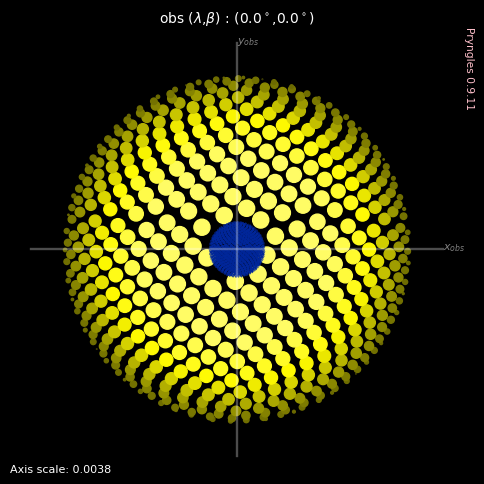

In [7]:
system.sg.plot2d()

## **Set Temperature Models**

In [8]:
T_zhang_showman_model = {
    "type": "Zhang-Showman",
    "params": dict(T_night = wasp_params['T_n'],
                   Delta_T = wasp_params['delta_T'],
                   xi_ratio = wasp_params['xi'])}

planet.set_temperature_model(T_zhang_showman_model)

planet.T_model

{'type': 'Zhang-Showman',
 'params': {'T_night': 1128, 'Delta_T': 942, 'xi_ratio': 0.3}}

## **Setting up Detector**

In [9]:
DETECTOR_PROPERTIES = dict(
    # Waveband
    wavelength_min = 500e-9, # [m]
    wavelength_max = 700e-9, # [m] 
    # Apperture
    apperture = 0.5, # [m]
    # Quantum Efficiency
    quantum_eff = 1,
    # Time of Cadence    
    t_cadence = 10*60, # Minutes [s]
    # Observer Distance
    distance = 1*1e3*pr.Consts.pc # Kilo Parsec [m]
)

## **Computing Lightcurve**

In [10]:
# Times for integration
ts = np.linspace(-wasp_params['per']/2, wasp_params['per']/2, 100) # [days]


# Testing compute_lightcurve Method
system.compute_lightcurve(times = ts*pr.Consts.day/system.ut, bandwidth=(wasp_params['l1'], wasp_params['l2']),
                          effects = ['transit', 'reflection', 'emission'],
                          signal = DETECTOR_PROPERTIES)

Computing Lightcurve :   0%|          | 0/100 [00:00<?, ?it/s]

Computing Lightcurve : 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]


{'times': array([-6.99676048e-03, -6.85541179e-03, -6.71406309e-03, -6.57271439e-03,
        -6.43136570e-03, -6.29001700e-03, -6.14866830e-03, -6.00731961e-03,
        -5.86597091e-03, -5.72462221e-03, -5.58327352e-03, -5.44192482e-03,
        -5.30057612e-03, -5.15922743e-03, -5.01787873e-03, -4.87653003e-03,
        -4.73518134e-03, -4.59383264e-03, -4.45248394e-03, -4.31113525e-03,
        -4.16978655e-03, -4.02843785e-03, -3.88708916e-03, -3.74574046e-03,
        -3.60439176e-03, -3.46304307e-03, -3.32169437e-03, -3.18034567e-03,
        -3.03899698e-03, -2.89764828e-03, -2.75629958e-03, -2.61495089e-03,
        -2.47360219e-03, -2.33225349e-03, -2.19090480e-03, -2.04955610e-03,
        -1.90820740e-03, -1.76685871e-03, -1.62551001e-03, -1.48416131e-03,
        -1.34281262e-03, -1.20146392e-03, -1.06011522e-03, -9.18766528e-04,
        -7.77417831e-04, -6.36069135e-04, -4.94720438e-04, -3.53371742e-04,
        -2.12023045e-04, -7.06743483e-05,  7.06743483e-05,  2.12023045e-04,
   

### **Lightcurve Configuration Parameters**

In [15]:
# Metadata Attribute
system.lightcurve['flux']

array([1.        , 1.        , 1.        , 1.00004522, 1.00072563,
       1.00070378, 1.00067988, 1.00065415, 1.00062685, 1.00059822,
       1.00056853, 1.00053804, 1.00050701, 1.00047571, 1.00044439,
       1.0004133 , 1.00038267, 1.00035271, 1.00032362, 1.00029559,
       1.00026876, 1.00024326, 1.0002192 , 1.00019667, 1.00017572,
       1.00015639, 1.00013867, 1.00012257, 1.00010805, 1.00009507,
       1.00008354, 1.0000734 , 1.00006457, 1.00005695, 1.00005043,
       1.00004493, 1.00004033, 1.00003654, 1.00003347, 1.00003101,
       1.00002909, 1.00002764, 1.00002658, 1.00002586, 1.00002541,
       1.00002519, 0.99454352, 0.97470175, 0.97470202, 0.9747024 ,
       0.97470293, 0.97470363, 0.9747046 , 0.99451378, 1.0000313 ,
       1.0000337 , 1.00003682, 1.00004077, 1.00004569, 1.00005169,
       1.0000589 , 1.00006744, 1.00007741, 1.0000889 , 1.00010199,
       1.00011674, 1.00013319, 1.00015136, 1.00017125, 1.00019282,
       1.00021603, 1.00024079, 1.000267  , 1.00029453, 1.00032

### **Effects Contribution Model**

In [12]:
system.lightcurve['model']

body          Planet                  
effect    reflection transit  emission
time                                  
-0.006997   0.000000    -0.0  0.000000
-0.006855   0.000000    -0.0  0.000000
-0.006714   0.000000    -0.0  0.000000
-0.006573   0.000021    -0.0  0.000024
-0.006431   0.000177    -0.0  0.000548
...              ...     ...       ...
 0.006431   0.000177    -0.0  0.000628
 0.006573   0.000022    -0.0  0.000103
 0.006714   0.000000    -0.0  0.000000
 0.006855   0.000000    -0.0  0.000000
 0.006997   0.000000    -0.0  0.000000

[100 rows x 3 columns]

## **Plot Lightcurve**

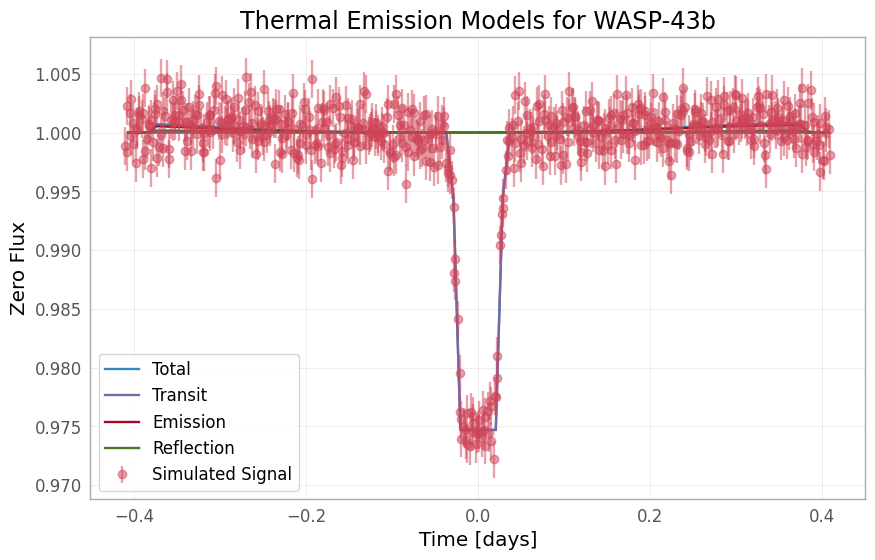

In [26]:
plt.figure(figsize=(10,6))

plt.plot(ts, system.lightcurve['flux'], label = 'Total', color = 'C0')

plt.plot(ts, 1 + system.lightcurve['model'][('Planet','transit')], label = 'Transit', color = 'C1')
plt.plot(ts, 1 + system.lightcurve['model'][('Planet','emission')], label = 'Emission', color = 'C2')
plt.plot(ts, 1 + system.lightcurve['model'][('Planet','reflection')], label = 'Reflection', color = 'C3')

plt.errorbar(system.detector.times/pr.Consts.days, system.detector.signal_flux, yerr = system.detector.signal_error, fmt = 'o', label = 'Simulated Signal', color = 'C4', alpha=0.5)

plt.xlabel('Time [days]')
plt.ylabel('Zero Flux')
plt.title('Thermal Emission Models for WASP-43b')

plt.legend()
plt.grid(linewidth=0.5, alpha=0.3)

plt.show()